In [3]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, LayerNormalization, Dropout, Flatten, MultiHeadAttention, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tqdm import tqdm

# 1. Chargement et traitement des séries temporelles sous forme de séquences fixes
print("\n🔹 Chargement et segmentation des séries temporelles...")
def load_time_series(directory, sequence_length=100):
    ids = os.listdir(directory)
    sequences, labels = [], []
    for id_dir in tqdm(ids):
        file_path = os.path.join(directory, id_dir, 'part-0.parquet')
        if os.path.exists(file_path):
            df = pd.read_parquet(file_path)
            df['id'] = id_dir  # Associer l'ID du participant
            if 'step' in df.columns:
                df = df.drop('step', axis=1)  # Supprimer la colonne inutile
            for i in range(0, len(df) - sequence_length, sequence_length):
                sequences.append(df.iloc[i:i+sequence_length, :-1].values)  # Exclure la colonne ID
                labels.append(id_dir)
    return np.array(sequences), np.array(labels)

series_train, series_ids = load_time_series("C:/Users/nabil/Desktop/Deep_learning_4IABD/data/series_train.parquet")
train_df = pd.read_csv("C:/Users/nabil/Desktop/Deep_learning_4IABD/data/train.csv")

# 2. Fusion des séries temporelles avec train.csv
print("\n🔹 Fusion des séries temporelles avec les métadonnées...")
train_df = train_df.set_index('id')
labels = np.array([train_df.loc[id, 'SII'] for id in series_ids])

# 3. Normalisation des séries temporelles
scaler = StandardScaler()
series_train = scaler.fit_transform(series_train.reshape(-1, series_train.shape[-1])).reshape(series_train.shape)

# 4. Encodage des labels
print("\n🔹 Encodage des labels...")
encoder = OneHotEncoder(sparse=False)
labels = encoder.fit_transform(labels.reshape(-1, 1))

# 5. Séparation en train/val
x_train, x_val, y_train, y_val = train_test_split(series_train, labels, test_size=0.2, random_state=42)

# 6. Positional Encoding pour le Transformer
class PositionalEncoding(keras.layers.Layer):
    def __init__(self, sequence_length, d_model):
        super(PositionalEncoding, self).__init__()
        self.sequence_length = sequence_length
        self.d_model = d_model

    def build(self, input_shape):
        positions = np.arange(self.sequence_length)[:, np.newaxis]
        div_terms = np.exp(np.arange(0, self.d_model, 2) * -(np.log(10000.0) / self.d_model))
        pos_enc = np.zeros((self.sequence_length, self.d_model))
        pos_enc[:, 0::2] = np.sin(positions * div_terms)
        pos_enc[:, 1::2] = np.cos(positions * div_terms)
        self.positional_encoding = tf.cast(pos_enc[np.newaxis, ...], dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.positional_encoding[:, :tf.shape(inputs)[1], :]

# 7. Modèle Transformer avec Q, K, V
print("\n🔹 Construction du modèle Transformer avec Positional Encoding...")
def build_transformer_model(sequence_length, feature_dim, d_model=64, num_heads=4, ff_dim=128, num_layers=3, dropout=0.1):
    inputs = Input(shape=(sequence_length, feature_dim))
    x = Dense(d_model)(inputs)
    x = PositionalEncoding(sequence_length, d_model)(x)

    for _ in range(num_layers):
        Q = Dense(d_model)(x)
        K = Dense(d_model)(x)
        V = Dense(d_model)(x)
        attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(Q, K, V)
        attention_output = Dropout(dropout)(attention_output)
        x = LayerNormalization(epsilon=1e-6)(x + attention_output)
        ffn_output = Dense(ff_dim, activation='relu')(x)
        ffn_output = Dense(d_model)(ffn_output)
        ffn_output = Dropout(dropout)(ffn_output)
        x = LayerNormalization(epsilon=1e-6)(x + ffn_output)
    
    x = Flatten()(x)
    outputs = Dense(4, activation="softmax")(x)  # 4 classes pour la classification

    model = Model(inputs, outputs)
    model.compile(optimizer=AdamW(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# 8. Entraînement et évaluation du modèle
print("\n🔹 Entraînement du modèle Transformer...")
model = build_transformer_model(sequence_length=100, feature_dim=series_train.shape[-1])
model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=32)

print("\n✅ Modèle entraîné avec succès !")



🔹 Chargement et segmentation des séries temporelles...


  1%|          | 6/996 [03:54<10:45:07, 39.10s/it]


KeyboardInterrupt: 

In [27]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, LayerNormalization, Dropout, Flatten, MultiHeadAttention, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tqdm import tqdm

# 1. Chargement et traitement des séries temporelles sous forme de séquences fixes
print("\n🔹 Chargement et segmentation des 100 premiers fichiers de séries temporelles...")
def load_time_series(directory, sequence_length=100, max_files=100):
    ids = os.listdir(directory)[:max_files]  # Ne prendre que les 100 premiers fichiers
    sequences, labels = [], []
    for id_dir in tqdm(ids):
        file_path = os.path.join(directory, id_dir, 'part-0.parquet')
        if os.path.exists(file_path):
            df = pd.read_parquet(file_path)
            df['id'] = id_dir  # Associer l'ID du participant
            if 'step' in df.columns:
                df = df.drop('step', axis=1)  # Supprimer la colonne inutile
            for i in range(0, len(df) - sequence_length, sequence_length):
                sequences.append(df.iloc[i:i+sequence_length, :-1].values)  # Exclure la colonne ID
                labels.append(id_dir)
    return np.array(sequences), np.array(labels)

series_train, series_ids = load_time_series("C:/Users/nabil/Desktop/Deep_learning_4IABD/data/series_train.parquet", max_files=10)
train_df = pd.read_csv("C:/Users/nabil/Desktop/Deep_learning_4IABD/data/train.csv")




🔹 Chargement et segmentation des 100 premiers fichiers de séries temporelles...


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [05:36<00:00, 33.68s/it]


In [33]:
# 2. Suppression des NaN dans 'sii' dès le début
train_df = train_df.dropna(subset=['sii'])

train_df['sii'] = train_df['sii'].astype(int)  # S'assurer que les labels sont bien entiers
print("Valeurs uniques dans train_df['sii'] après conversion :", train_df['sii'].unique())

# 3. Fusion des séries temporelles avec train.csv
print("\n🔹 Fusion des séries temporelles avec les métadonnées...")


labels = np.array([train_df[train_df['id'] == id]['sii'].values[0] if id in train_df['id'].values else np.nan for id in series_ids])

# Remplace les NaN par une classe par défaut (ex: 0 pour 'None')
# labels = np.nan_to_num(labels, nan=0.0)

# 4. Normalisation des séries temporelles
scaler = StandardScaler()
series_train = scaler.fit_transform(series_train.reshape(-1, series_train.shape[-1])).reshape(series_train.shape)




# 5. Encodage des labels
print("\n🔹 Encodage des labels...")
# Vérifier les valeurs uniques après suppression des NaN
print("Valeurs uniques de labels avant encodage:", np.unique(labels))

# Vérifier la forme des labels avant encodage
print("Shape des labels avant encodage:", labels.shape)

# Correction pour assurer un encodage one-hot correct
labels = labels.astype(int)  # Convertir en entier si nécessaire
labels = labels.reshape(-1, 1) if labels.ndim == 1 else labels
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
labels = encoder.fit_transform(labels)

# Vérification après encodage
print("Shape des labels après OneHotEncoder:", labels.shape)  # Devrait être (N, 4)
print("Exemple de labels après encodage:", labels[:5])

# 6. Séparation en train/val
x_train, x_val, y_train, y_val = train_test_split(series_train, labels, test_size=0.2, random_state=42)

# 7. Positional Encoding pour le Transformer
class PositionalEncoding(keras.layers.Layer):
    def __init__(self, sequence_length, d_model):
        super(PositionalEncoding, self).__init__()
        self.sequence_length = sequence_length
        self.d_model = d_model

    def build(self, input_shape):
        positions = np.arange(self.sequence_length)[:, np.newaxis]
        div_terms = np.exp(np.arange(0, self.d_model, 2) * -(np.log(10000.0) / self.d_model))
        pos_enc = np.zeros((self.sequence_length, self.d_model))
        pos_enc[:, 0::2] = np.sin(positions * div_terms)
        pos_enc[:, 1::2] = np.cos(positions * div_terms)
        self.positional_encoding = tf.cast(pos_enc[np.newaxis, ...], dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.positional_encoding[:, :tf.shape(inputs)[1], :]

# 8. Modèle Transformer avec Q, K, V
print("\n🔹 Construction du modèle Transformer avec Positional Encoding...")
def build_transformer_model(sequence_length, feature_dim, d_model=64, num_heads=4, ff_dim=128, num_layers=3, dropout=0.1):
    inputs = Input(shape=(sequence_length, feature_dim))
    x = Dense(d_model)(inputs)
    x = PositionalEncoding(sequence_length, d_model)(x)

    for _ in range(num_layers):
        Q = Dense(d_model)(x)
        K = Dense(d_model)(x)
        V = Dense(d_model)(x)
        attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(Q, K, V)
        attention_output = Dropout(dropout)(attention_output)
        x = LayerNormalization(epsilon=1e-6)(x + attention_output)
        ffn_output = Dense(ff_dim, activation='relu')(x)
        ffn_output = Dense(d_model)(ffn_output)
        ffn_output = Dropout(dropout)(ffn_output)
        x = LayerNormalization(epsilon=1e-6)(x + ffn_output)
    
    x = Flatten()(x)
    outputs = Dense(4, activation="softmax")(x)  # 4 classes pour la classification

    model = Model(inputs, outputs)
    model.compile(optimizer=AdamW(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# 9. Entraînement et évaluation du modèle
print("\n🔹 Entraînement du modèle Transformer...")
model = build_transformer_model(sequence_length=100, feature_dim=series_train.shape[-1])
model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=32)

print("\n✅ Modèle entraîné avec succès !")


Valeurs uniques dans train_df['sii'] après conversion : [2 0 1 3]

🔹 Fusion des séries temporelles avec les métadonnées...

🔹 Encodage des labels...
Valeurs uniques de labels avant encodage: [nan]
Shape des labels avant encodage: (32408,)
Shape des labels après OneHotEncoder: (32408, 1)
Exemple de labels après encodage: [[1.]
 [1.]
 [1.]
 [1.]
 [1.]]

🔹 Construction du modèle Transformer avec Positional Encoding...

🔹 Entraînement du modèle Transformer...


C:\Users\nabil\AppData\Local\Temp\ipykernel_9316\3793037772.py:32: RuntimeWarning: invalid value encountered in cast
  labels = labels.astype(int)  # Convertir en entier si nécessaire


Epoch 1/30


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 1), output.shape=(None, 4)

In [40]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, LayerNormalization, Dropout, Flatten, MultiHeadAttention
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tqdm import tqdm

# 1️⃣ Chargement et traitement des séries temporelles
print("\n🔹 Chargement et segmentation des 100 premiers fichiers de séries temporelles...")

def load_time_series(directory, max_files=100):
    ids = os.listdir(directory)[:max_files]  # Ne prend que les 100 premiers fichiers
    sequences, all_ids = [], []
    
    for id_dir in tqdm(ids):
        file_path = os.path.join(directory, id_dir, 'part-0.parquet')
        if os.path.exists(file_path):
            df = pd.read_parquet(file_path)
            df['id'] = id_dir  # Associer l'ID du participant
            
            if 'step' in df.columns:
                df = df.drop('step', axis=1)  # Supprimer la colonne inutile
                
            df = df.select_dtypes(include=[np.number])  # Garder uniquement les colonnes numériques
            sequences.append(df.mean().values)  # Prendre la moyenne des features
            all_ids.append(id_dir)

    series_df = pd.DataFrame(sequences, columns=[f"feature_{i}" for i in range(len(sequences[0]))])
    series_df['id'] = all_ids  # Ajouter les IDs
    return series_df

# Charger les séries temporelles et les données tabulaires
series_train_df = load_time_series("C:/Users/nabil/Desktop/Deep_learning_4IABD/data/series_train.parquet", max_files=6)
tabular_train_df = pd.read_csv("C:/Users/nabil/Desktop/Deep_learning_4IABD/data/train.csv")

# 2️⃣ Suppression des NaN dans 'sii' dès le début
tabular_train_df = tabular_train_df.dropna(subset=['sii'])

# 3️⃣ Fusionner les données tabulaires et temporelles
print("\n🔹 Fusion des données tabulaires et temporelles...")
train_df = pd.merge(tabular_train_df, series_train_df, how='left', on='id')

# 4️⃣ Encodage des variables catégorielles
train_df = pd.get_dummies(train_df)

# 5️⃣ Séparation des labels
labels = train_df['sii'].astype(int).values
train_df = train_df.drop(columns=['sii', 'id'], errors='ignore')  # Supprimer la colonne ID et label après extraction
train_df = train_df.fillna(0)  # Remplace NaN par 0

# 6️⃣ Normalisation des features
scaler = StandardScaler()
train_df = pd.DataFrame(scaler.fit_transform(train_df), columns=train_df.columns)

# 7️⃣ Encodage des labels
print("\n🔹 Encodage des labels...")
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
labels = labels.reshape(-1, 1) if labels.ndim == 1 else labels
labels = encoder.fit_transform(labels)

# Vérification de la forme des labels après encodage
print("Shape des labels après OneHotEncoder:", labels.shape)
print("Exemple de labels après encodage:", labels[:5])

# 8️⃣ Séparation en train/val
x_train, x_val, y_train, y_val = train_test_split(train_df, labels, test_size=0.2, random_state=42)

# 🚀 **Ajout d'une dimension temporelle pour le Transformer**
x_train = x_train.values.reshape(x_train.shape[0], 1, x_train.shape[1])
x_val = x_val.values.reshape(x_val.shape[0], 1, x_val.shape[1])


# 9️⃣ Positional Encoding pour le Transformer
class PositionalEncoding(keras.layers.Layer):
    def __init__(self, sequence_length, d_model):
        super(PositionalEncoding, self).__init__()
        self.sequence_length = sequence_length
        self.d_model = d_model

    def build(self, input_shape):
        positions = np.arange(self.sequence_length)[:, np.newaxis]
        div_terms = np.exp(np.arange(0, self.d_model, 2) * -(np.log(10000.0) / self.d_model))
        pos_enc = np.zeros((self.sequence_length, self.d_model))
        pos_enc[:, 0::2] = np.sin(positions * div_terms)
        pos_enc[:, 1::2] = np.cos(positions * div_terms)
        self.positional_encoding = tf.cast(pos_enc[np.newaxis, ...], dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.positional_encoding[:, :tf.shape(inputs)[1], :]

# 🔟 Modèle Transformer avec Q, K, V
print("\n🔹 Construction du modèle Transformer avec Positional Encoding...")

def build_transformer_model(sequence_length, feature_dim, d_model=64, num_heads=4, ff_dim=128, num_layers=3, dropout=0.1):
    inputs = Input(shape=(sequence_length, feature_dim))
    x = Dense(d_model)(inputs)
    x = PositionalEncoding(sequence_length, d_model)(x)

    for _ in range(num_layers):
        Q = Dense(d_model)(x)
        K = Dense(d_model)(x)
        V = Dense(d_model)(x)
        attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(Q, K, V)
        attention_output = Dropout(dropout)(attention_output)
        x = LayerNormalization(epsilon=1e-6)(x + attention_output)
        ffn_output = Dense(ff_dim, activation='relu')(x)
        ffn_output = Dense(d_model)(ffn_output)
        ffn_output = Dropout(dropout)(ffn_output)
        x = LayerNormalization(epsilon=1e-6)(x + ffn_output)
    
    x = Flatten()(x)
    outputs = Dense(4, activation="softmax")(x)  # 4 classes pour la classification

    model = Model(inputs, outputs)
    model.compile(optimizer=AdamW(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# 1️⃣1️⃣ Entraînement et évaluation du modèle
print("\n🔹 Entraînement du modèle Transformer...")
model = build_transformer_model(sequence_length=1, feature_dim=train_df.shape[-1])
model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=30, batch_size=32)

print("\n✅ Modèle entraîné avec succès !")



🔹 Chargement et segmentation des 100 premiers fichiers de séries temporelles...


  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 11.03it/s]



🔹 Fusion des données tabulaires et temporelles...

🔹 Encodage des labels...
Shape des labels après OneHotEncoder: (2736, 4)
Exemple de labels après encodage: [[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]]

🔹 Construction du modèle Transformer avec Positional Encoding...

🔹 Entraînement du modèle Transformer...
Epoch 1/30


C:\Users\nabil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\ops\nn.py:545: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


69/69 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.4222 - loss: 1.3957 - val_accuracy: 0.5785 - val_loss: 0.9934
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.6374 - loss: 0.8471 - val_accuracy: 0.6314 - val_loss: 0.8567
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.7250 - loss: 0.6570 - val_accuracy: 0.6825 - val_loss: 0.7539
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8182 - loss: 0.4862 - val_accuracy: 0.7336 - val_loss: 0.6893
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.8743 - loss: 0.3387 - val_accuracy: 0.7354 - val_loss: 0.6747
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9205 - loss: 0.2440 - val_accuracy: 0.7464 - val_loss: 0.7108
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9620 - loss: 0.1435 - val_accuracy: 0.7445 - val_loss: 0.7435
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9743 - loss: 0.1014 - val_accuracy: 0.7372 - val_loss: 0

In [9]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, LayerNormalization, Dropout, MultiHeadAttention, Conv1D, LSTM, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tqdm import tqdm

# 1️⃣ Chargement des séries temporelles sans perte d'information
def load_time_series(directory, max_files=100, sequence_length=30):
    ids = os.listdir(directory)[:max_files]  # Limite à 100 fichiers
    sequences, all_ids = [], []
    
    for id_dir in tqdm(ids):
        file_path = os.path.join(directory, id_dir, 'part-0.parquet')
        if os.path.exists(file_path):
            df = pd.read_parquet(file_path)
            df['id'] = id_dir  # Associer l'ID du participant
            
            if 'step' in df.columns:
                df = df.drop('step', axis=1)  # Supprimer la colonne inutile
                
            df = df.select_dtypes(include=[np.number])  # Garder uniquement les colonnes numériques
            
            if len(df) >= sequence_length:
                df = df.iloc[:sequence_length]  # Prendre une fenêtre de taille fixe
                sequences.append(df.values)
                all_ids.append(id_dir)
    
    return np.array(sequences), all_ids

# Définition du modèle Transformer
def build_transformer_model(sequence_length, feature_dim, tabular_dim, num_classes, d_model=64, num_heads=4, ff_dim=128, num_layers=3, dropout=0.1):
    series_input = Input(shape=(sequence_length, feature_dim))
    tabular_input = Input(shape=(tabular_dim,))
    
    x = Dense(d_model)(series_input)
    
    for _ in range(num_layers):
        Q = Dense(d_model)(x)
        K = Dense(d_model)(x)
        V = Dense(d_model)(x)
        attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(Q, K, V)
        attention_output = Dropout(dropout)(attention_output)
        x = LayerNormalization(epsilon=1e-6)(x + attention_output)
        ffn_output = Dense(ff_dim, activation='relu')(x)
        ffn_output = Dense(d_model)(ffn_output)
        ffn_output = Dropout(dropout)(ffn_output)
        x = LayerNormalization(epsilon=1e-6)(x + ffn_output)
    
    x = Flatten()(x)
    tabular_x = Dense(32, activation='relu')(tabular_input)
    tabular_x = Dense(16, activation='relu')(tabular_x)
    
    concat = keras.layers.concatenate([x, tabular_x])
    outputs = Dense(num_classes, activation="softmax")(concat)
    
    model = Model([series_input, tabular_input], outputs)
    model.compile(optimizer=AdamW(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# Charger les séries temporelles et les données tabulaires
sequence_length = 30  # Taille des séquences
series_train, series_ids = load_time_series("C:/Users/nabil/Desktop/Deep_learning_4IABD/data/series_train.parquet", max_files=100, sequence_length=sequence_length)
tabular_train_df = pd.read_csv("C:/Users/nabil/Desktop/Deep_learning_4IABD/data/train.csv")

# Vérifications initiales
print("Avant dropna, shape :", tabular_train_df.shape)
tabular_train_df = tabular_train_df.dropna(subset=['sii'])
print("Après dropna, shape :", tabular_train_df.shape)

# Nettoyage et conversion des IDs
tabular_train_df['id'] = tabular_train_df['id'].astype(str)
series_ids = [id_.replace("id=", "") for id_ in series_ids]
series_ids = list(map(str, series_ids))

# Assurer la correspondance des IDs
tabular_train_df = tabular_train_df[tabular_train_df['id'].isin(series_ids)].copy()
series_train = np.array([series_train[series_ids.index(id_)] for id_ in tabular_train_df['id']])

print("Nouvelle shape de series_train :", series_train.shape)
print("Nouvelle shape de tabular_train_df :", tabular_train_df.shape)

# Séparation des labels
labels = tabular_train_df['sii'].astype(int).values
num_classes = len(np.unique(labels))
print("Nombre de classes uniques détectées :", num_classes)

# Encodage des labels
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
labels = encoder.fit_transform(labels.reshape(-1, 1))
print("Shape des labels après encodage :", labels.shape)

# Normalisation des features
train_df = tabular_train_df.drop(columns=['sii', 'id'], errors='ignore')
numeric_features = train_df.select_dtypes(include=[np.number])
tabular_features = StandardScaler().fit_transform(numeric_features)

# Séparation en train/val
x_train, x_val, y_train, y_val, tab_train, tab_val = train_test_split(series_train, labels, tabular_features, test_size=0.2, random_state=42)

# Entraînement du modèle
model = build_transformer_model(sequence_length=sequence_length, feature_dim=series_train.shape[-1], tabular_dim=tabular_features.shape[1], num_classes=num_classes)
model.fit([x_train, tab_train], y_train, validation_data=([x_val, tab_val], y_val), epochs=30, batch_size=32)

print("\n✅ Modèle entraîné avec succès !")


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:05<00:00, 17.28it/s]


Avant dropna, shape : (3960, 82)
Après dropna, shape : (2736, 82)
Nouvelle shape de series_train : (100, 30, 12)
Nouvelle shape de tabular_train_df : (100, 82)
Nombre de classes uniques détectées : 3
Shape des labels après encodage : (100, 3)
Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 608ms/step - accuracy: 0.4109 - loss: 1.1942 - val_accuracy: 0.4500 - val_loss: 1.1760
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.5164 - loss: 0.9996 - val_accuracy: 0.4500 - val_loss: 1.2100
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.4617 - loss: 1.0600 - val_accuracy: 0.4500 - val_loss: 1.2324
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.5164 - loss: 0.9742 - val_accuracy: 0.4500 - val_loss: 1.2615
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.5469 - loss: 1.0519 - val_accuracy: 0.4500 - val_loss: 1.1383
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5344 - loss: 0.9500 - val_accuracy: 0.4500 - val_loss: 1.0963
E

In [11]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, LayerNormalization, Dropout, MultiHeadAttention, Conv1D, LSTM, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tqdm import tqdm

# 1️⃣ Chargement des séries temporelles sans perte d'information
def load_time_series(directory, max_files=100, sequence_length=30):
    ids = os.listdir(directory)[:max_files]  # Limite à 100 fichiers
    sequences, all_ids = [], []
    
    for id_dir in tqdm(ids):
        file_path = os.path.join(directory, id_dir, 'part-0.parquet')
        if os.path.exists(file_path):
            df = pd.read_parquet(file_path)
            df['id'] = id_dir  # Associer l'ID du participant
            
            if 'step' in df.columns:
                df = df.drop('step', axis=1)  # Supprimer la colonne inutile
                
            df = df.select_dtypes(include=[np.number])  # Garder uniquement les colonnes numériques
            
            if len(df) >= sequence_length:
                df = df.iloc[:sequence_length]  # Prendre une fenêtre de taille fixe
                sequences.append(df.values)
                all_ids.append(id_dir)
    
    return np.array(sequences), all_ids

# Ajout du Positional Encoding
class PositionalEncoding(keras.layers.Layer):
    def __init__(self, sequence_length, d_model):
        super(PositionalEncoding, self).__init__()
        self.sequence_length = sequence_length
        self.d_model = d_model
        
    def build(self, input_shape):
        positions = np.arange(self.sequence_length)[:, np.newaxis]
        div_terms = np.exp(np.arange(0, self.d_model, 2) * -(np.log(10000.0) / self.d_model))
        pos_enc = np.zeros((self.sequence_length, self.d_model))
        pos_enc[:, 0::2] = np.sin(positions * div_terms)
        pos_enc[:, 1::2] = np.cos(positions * div_terms)
        self.positional_encoding = tf.cast(pos_enc[np.newaxis, ...], dtype=tf.float32)
    
    def call(self, inputs):
        return inputs + self.positional_encoding[:, :tf.shape(inputs)[1], :]

# Définition du modèle Transformer
def build_transformer_model(sequence_length, feature_dim, tabular_dim, num_classes, d_model=64, num_heads=4, ff_dim=128, num_layers=3, dropout=0.1):
    series_input = Input(shape=(sequence_length, feature_dim))
    tabular_input = Input(shape=(tabular_dim,))
    
    x = Dense(d_model)(series_input)
    x = PositionalEncoding(sequence_length, d_model)(x)
    
    for _ in range(num_layers):
        Q = Dense(d_model)(x)
        K = Dense(d_model)(x)
        V = Dense(d_model)(x)
        attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(Q, K, V)
        attention_output = Dropout(dropout)(attention_output)
        x = LayerNormalization(epsilon=1e-6)(x + attention_output)
        ffn_output = Dense(ff_dim, activation='relu')(x)
        ffn_output = Dense(d_model)(ffn_output)
        ffn_output = Dropout(dropout)(ffn_output)
        x = LayerNormalization(epsilon=1e-6)(x + ffn_output)
    
    x = Flatten()(x)
    tabular_x = Dense(32, activation='relu')(tabular_input)
    tabular_x = Dense(16, activation='relu')(tabular_x)
    
    concat = keras.layers.concatenate([x, tabular_x])
    outputs = Dense(num_classes, activation="softmax")(concat)
    
    model = Model([series_input, tabular_input], outputs)
    model.compile(optimizer=AdamW(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

# Charger les séries temporelles et les données tabulaires
sequence_length = 30  # Taille des séquences
series_train, series_ids = load_time_series("C:/Users/nabil/Desktop/Deep_learning_4IABD/data/series_train.parquet", max_files=100, sequence_length=sequence_length)
tabular_train_df = pd.read_csv("C:/Users/nabil/Desktop/Deep_learning_4IABD/data/train.csv")

# Vérifications initiales
print("Avant dropna, shape :", tabular_train_df.shape)
tabular_train_df = tabular_train_df.dropna(subset=['sii'])
print("Après dropna, shape :", tabular_train_df.shape)

# Nettoyage et conversion des IDs
tabular_train_df['id'] = tabular_train_df['id'].astype(str)
series_ids = [id_.replace("id=", "") for id_ in series_ids]
series_ids = list(map(str, series_ids))

# Assurer la correspondance des IDs
tabular_train_df = tabular_train_df[tabular_train_df['id'].isin(series_ids)].copy()
series_train = np.array([series_train[series_ids.index(id_)] for id_ in tabular_train_df['id']])

print("Nouvelle shape de series_train :", series_train.shape)
print("Nouvelle shape de tabular_train_df :", tabular_train_df.shape)

# Séparation des labels
labels = tabular_train_df['sii'].astype(int).values
num_classes = len(np.unique(labels))
print("Nombre de classes uniques détectées :", num_classes)

# Encodage des labels
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
labels = encoder.fit_transform(labels.reshape(-1, 1))
print("Shape des labels après encodage :", labels.shape)

# Normalisation des features
train_df = tabular_train_df.drop(columns=['sii', 'id'], errors='ignore')
numeric_features = train_df.select_dtypes(include=[np.number])
tabular_features = StandardScaler().fit_transform(numeric_features)

# Séparation en train/val
x_train, x_val, y_train, y_val, tab_train, tab_val = train_test_split(series_train, labels, tabular_features, test_size=0.2, random_state=42)

# Entraînement du modèle
model = build_transformer_model(sequence_length=sequence_length, feature_dim=series_train.shape[-1], tabular_dim=tabular_features.shape[1], num_classes=num_classes)
history = model.fit([x_train, tab_train], y_train, validation_data=([x_val, tab_val], y_val), epochs=30, batch_size=32)

print("\n✅ Modèle entraîné avec succès !")


100%|██████████| 100/100 [00:09<00:00, 11.01it/s]


Avant dropna, shape : (3960, 82)
Après dropna, shape : (2736, 82)
Nouvelle shape de series_train : (100, 30, 12)
Nouvelle shape de tabular_train_df : (100, 82)
Nombre de classes uniques détectées : 3
Shape des labels après encodage : (100, 3)
Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 475ms/step - accuracy: 0.1172 - loss: 2.0873 - val_accuracy: 0.4500 - val_loss: 1.0835
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5727 - loss: 0.9796 - val_accuracy: 0.4500 - val_loss: 1.2947
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5922 - loss: 1.0153 - val_accuracy: 0.4500 - val_loss: 1.4129
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5617 - loss: 0.9902 - val_accuracy: 0.4500 - val_loss: 1.4367
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4609 - loss: 1.2333 - val_accuracy: 0.4500 - val_loss: 1.4256
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5281 - loss: 1.0641 - val_accuracy: 0.4500 - val_loss: 1.4271
Epoch

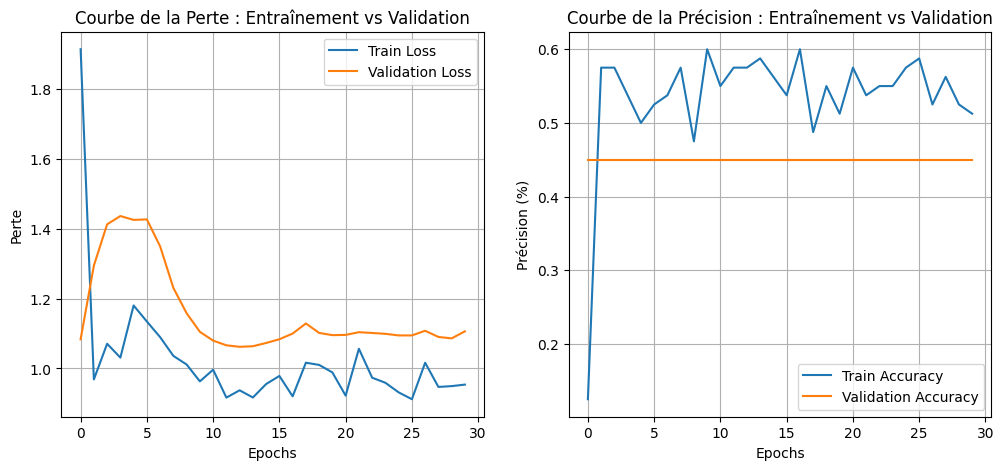

In [13]:
import matplotlib.pyplot as plt
# Fonction pour afficher les courbes d'entraînement
def plot_training_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Courbe de la perte
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Courbe de la Perte : Entraînement vs Validation')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Perte')
    axes[0].legend()
    axes[0].grid()
    
    # Courbe de la précision
    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_title('Courbe de la Précision : Entraînement vs Validation')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Précision (%)')
    axes[1].legend()
    axes[1].grid()
    
    plt.show()

plot_training_curves(history)